# VAMPS — Fiji stepwise run with explicit Python I/O

This notebook drives VAMPS entirely from Python, exposing every I/O step
that is normally hidden inside `Model.run_stepwise()`.  The goal is to show
each public function once, with its inputs and outputs labelled.

**Execution paths covered here**

| Step | Function | Module |
|------|----------|--------|
| Parse config file | `parse_inp()` | `vampspy._io` |
| Load forcing (spec string) | `load_ts_spec()` | `vampspy.forcing` |
| Load forcing (direct file) | `read_ts()` / `read_ts_timed()` | `vampspy.forcing` |
| Load forcing (whole directory) | `load_forcing_dir()` | `vampspy.forcing` |
| Write forcing files | `write_ts()` | `vampspy._io` |
| Write config file | `write_inp()` | `vampspy._io` |
| Initialise C solver | `_vampscore.soil_init()` | `vampspy._vampscore` |
| Step (canopy + Richards) | `_vampscore.soil_step()` | `vampspy._vampscore` |
| Collect state | `_vampscore.soil_state()` | `vampspy._vampscore` |
| Parse reference .out | `read_out()` / `parse_out()` | `vampspy._io` |

**Setup** (run once from the repo root):
```bash
pip install -e .
```

In [1]:
import os, sys, tempfile, pprint
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

REPO = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, REPO)

# Low-level I/O helpers
from vampspy._io import parse_inp, parse_out, read_out, write_inp, write_ts

# Forcing loaders
from vampspy.forcing import read_ts, read_ts_timed, load_ts_spec, load_forcing_dir

# C extension — stepwise API
from vampspy import _vampscore

DATA_DIR = os.path.join(REPO, 'examples', 'fiji')
INP      = os.path.join(DATA_DIR, 'fiji.inp')

print('repo :', REPO)
print('data :', DATA_DIR)
print('ext  :', _vampscore.__file__)

repo : /Users/jaap/Nextcloud/src/vamps
data : /Users/jaap/Nextcloud/src/vamps/examples/fiji
ext  : /Users/jaap/Nextcloud/src/vamps/vampspy/_vampscore.cpython-313-darwin.so


---
## 1. Parse the .inp config file — `parse_inp()`

`parse_inp(path)` reads a VAMPS INI-style config file and returns a nested dict
`{section: {key: value}}`.  Values are auto-converted to `int` / `float` where
possible; backslash-continued multi-token lines become Python `list`s.

In [2]:
sections = parse_inp(INP)

print(f"Sections found: {list(sections.keys())}\n")

print("[soil] section:")
pprint.pprint(sections['soil'])

print("\n[ts] section (forcing file specs):")
pprint.pprint(sections['ts'])

print("\n[top] system:", sections.get('top', {}).get('system'))

Sections found: ['vamps', 'run', 'determine', 'soilevaporation', 'top', 'time', 'ts', 'interception', 'canopy', 'roots', 'soil', 'layer_0', 'st_0', 'layer_14', 'st_1', 'layer_36', 'st_2']

[soil] section:
{'bottom': 6,
 'cofred': 0.35,
 'dtmax': 0.01,
 'dtmin': 0.0006,
 'dumptables': 1,
 'gwlevel': 1.0,
 'initprof': 0,
 'layers': 77,
 'mbck': 1,
 'mktable': 1,
 'outdir': 'output',
 'pondmx': 0.0,
 'swredu': 0,
 'theta_initial': [0.2,
                   0.21,
                   0.22,
                   0.22,
                   0.265,
                   0.3,
                   0.35,
                   0.375817,
                   0.377095,
                   0.383497,
                   0.38,
                   0.38,
                   0.38,
                   0.443651,
                   0.4,
                   0.4,
                   0.4,
                   0.4,
                   0.41,
                   0.42,
                   0.43,
                   0.44,
                   0.47,


---
## 2. Load forcing data — `forcing.py`

Four public functions cover the common loading patterns.

### 2a. `load_ts_spec(spec, base_dir)` — mirrors `[ts]` section entries

Accepts the raw right-hand side from a `[ts]` line:
* `"precip.prn"` — 2-column file, returns value column
* `"all.inp,0,2"` — multi-column file, `xcol=0`, `ycol=2`
* `"hg"` — special C keyword; returns `None` (C handles it)

In [3]:
ts_section = sections['ts']

forcing_spec = {}
passthrough  = {}
for name, spec in ts_section.items():
    arr = load_ts_spec(str(spec), DATA_DIR)
    if arr is not None:
        forcing_spec[name] = arr
        print(f"  {name:5s}  spec={str(spec)!r:30s}  shape={arr.shape}  range=[{arr.min():.3f}, {arr.max():.3f}]")
    else:
        passthrough[name] = spec
        print(f"  {name:5s}  spec={str(spec)!r:30s}  → passthrough (C keyword)")

  pre    spec='precip.prn'                    shape=(92,)  range=[0.000, 6.532]
  nra    spec='rnet.prn'                      shape=(92,)  range=[14.096, 215.808]
  ira    spec='inrad.prn'                     shape=(91,)  range=[27.286, 287.728]
  rlh    spec='rh.prn'                        shape=(92,)  range=[67.109, 97.691]
  tem    spec='newt.prn'                      shape=(61,)  range=[18.862, 24.735]
  win    spec='wind.prn'                      shape=(92,)  range=[0.941, 4.108]


### 2b. `read_ts(path)` and `read_ts_timed(path)` — direct file reads

In [4]:
precip_path = os.path.join(DATA_DIR, 'precip.prn')

# read_ts: returns only the value column
pre_vals = read_ts(precip_path)
print(f"read_ts        → shape {pre_vals.shape},  first 5: {pre_vals[:5]}")

# read_ts_timed: returns (times, values)
pre_t, pre_v = read_ts_timed(precip_path)
print(f"read_ts_timed  → times {pre_t[:3]} ... values {pre_v[:3]}")

read_ts        → shape (92,),  first 5: [0.         0.         0.         0.         0.24120048]
read_ts_timed  → times [33056. 33057. 33058.] ... values [0. 0. 0.]


### 2c. `load_forcing_dir(directory, names)` — bulk load from a directory

In [5]:
forcing = load_forcing_dir(
    DATA_DIR,
    names=['precip', 'rnet', 'inrad', 'rh', 'newt', 'wind'],
)

# Rename to the keys VAMPS expects in [ts]
forcing = {
    'pre': forcing['precip'],
    'nra': forcing['rnet'],
    'ira': forcing['inrad'],
    'rlh': forcing['rh'],
    'tem': forcing['newt'],
    'win': forcing['wind'],
}

STEPS = 61
forcing = {k: v[:STEPS] for k, v in forcing.items()}

print("Forcing arrays loaded:")
for k, v in forcing.items():
    print(f"  {k}: shape={v.shape}  mean={v.mean():.3f}")

Forcing arrays loaded:
  pre: shape=(61,)  mean=0.422
  nra: shape=(61,)  mean=119.349
  ira: shape=(61,)  mean=168.735
  rlh: shape=(61,)  mean=83.073
  tem: shape=(61,)  mean=21.596
  win: shape=(61,)  mean=1.786


---
## 3. Write forcing and config files — `write_ts()`, `write_inp()`

These are the functions `Model._run_subprocess()` uses internally.
Here we call them explicitly so you can inspect the generated files.

In [6]:
tmpdir = tempfile.mkdtemp(prefix='vamps_sw_')
print(f"Working directory: {tmpdir}\n")

# --- write_ts: one .ts file per forcing variable ---
ts_paths = {}
for name, arr in forcing.items():
    path = os.path.join(tmpdir, f"{name}.ts")
    write_ts(arr, path, firststep=1)
    ts_paths[name] = path

print("Forcing files written:")
for name, path in ts_paths.items():
    print(f"  {name}: {os.path.basename(path)}")

# Preview the first three lines of precip.ts
print("\nFirst 3 lines of pre.ts:")
with open(ts_paths['pre']) as f:
    for _ in range(3):
        print(' ', f.readline(), end='')

Working directory: /var/folders/x3/40_90rdx27q5k8_sycvnhjw80000gn/T/vamps_sw_9i7u4sia

Forcing files written:
  pre: pre.ts
  nra: nra.ts
  ira: ira.ts
  rlh: rlh.ts
  tem: tem.ts
  win: win.ts

First 3 lines of pre.ts:
  1	0.00000000
  2	0.00000000
  3	0.00000000


In [7]:
import copy

# Build the config dict from the parsed .inp, stripping output-related sections
config = copy.deepcopy(sections)
config.pop('run',  None)
config.pop('xout', None)
config.pop('ts',   None)          # will be re-injected by write_inp
config.setdefault('vamps', {})['logging'] = 0
config.setdefault('time', {})['steps'] = STEPS

inp_path = os.path.join(tmpdir, 'run.inp')
out_path = os.path.join(tmpdir, 'run.out')  # used only by subprocess path

# --- write_inp: generates the full INI file ---
write_inp(config, inp_path, out_path, ts_paths, firststep=1)

# Preview the first 30 lines
print(f"Generated {inp_path}\n")
with open(inp_path) as f:
    lines = f.readlines()
for i, line in enumerate(lines[:30]):
    print(f"{i+1:3d}  {line}", end='')
if len(lines) > 30:
    print(f"     ... ({len(lines)-30} more lines)")

Generated /var/folders/x3/40_90rdx27q5k8_sycvnhjw80000gn/T/vamps_sw_9i7u4sia/run.inp

  1  [vamps]
  2  iniinmem = 1
  3  xtrapy = fiji.py
  4  logging = 0
  5  
  6  [determine]
  7  soilmoisture = 1
  8  
  9  [soilevaporation]
 10  method = 4
 11  
 12  [top]
 13  system = 5
 14  
 15  [time]
 16  steps = 61
 17  firststep = 1
 18  
 19  [interception]
 20  method = 0
 21  E_avg/R = 0.147
 22  p_f = 0.6
 23  p_tr = 0.017
 24  S = 0.08
 25  St = 0.0062
 26  
 27  [canopy]
 28  transpiration = 2
 29  Rnet_absorb = 0.975
 30  method = 2
     ... (100 more lines)


---
## 4. Stepwise Python loop

The stepwise API exposes three C functions:

| Function | What it does |
|----------|--------------|
| `soil_init(inp_path, forcing, firststep)` | Reset all C state; read config; register forcing arrays |
| `soil_step(i)` | Run canopy (`tstep_top`) + Richards solver for step `i` |
| `soil_state(i)` | Copy C globals → Python dict for step `i` |

The outer loop lives entirely in Python.  This means you can inspect,
print, or even modify values between steps.

In [ ]:
# Initialise: resets C globals, reads config, loads forcing into the ts registry
with open(inp_path) as _f:
    _ini_text = _f.read()
_vampscore.soil_init(_ini_text, forcing, 1.0)

nl = _vampscore.soil_nlayers()
print(f"Solver initialised: {nl} soil layers, {STEPS} steps")

In [9]:
per_step = []

for i in range(STEPS):
    # --- Run canopy + Richards solver for this external timestep ---
    _vampscore.soil_step(i)

    # --- Collect state: scalars + all profile arrays ---
    state = _vampscore.soil_state(i)
    per_step.append(state)

    # Example: inspect state mid-run (every 10 steps)
    if i % 10 == 0:
        print(f"  step {i+1:3d}  t={state['t']:.1f}  "
              f"SMD={state['SMD']:.3f}  volact={state['volact']:.3f}  "
              f"pre={state['precipitation']:.4f}  tra={state['transpiration']:.4f}")

print(f"\nLoop complete: {len(per_step)} steps collected")
print(f"Keys in each state dict: {list(per_step[0].keys())}")

  step   1  t=1.0  SMD=11.977  volact=69.238  pre=0.0000  tra=0.3553
  step  11  t=11.0  SMD=14.404  volact=66.785  pre=0.0000  tra=0.5295
  step  21  t=21.0  SMD=12.412  volact=68.742  pre=0.0000  tra=0.4810
  step  31  t=31.0  SMD=13.234  volact=67.886  pre=0.0402  tra=0.0000
  step  41  t=41.0  SMD=16.101  volact=64.977  pre=0.0000  tra=0.4929
  step  51  t=51.0  SMD=11.902  volact=70.760  pre=6.5325  tra=0.0000
  step  61  t=61.0  SMD=5.426  volact=79.245  pre=0.5025  tra=0.0000

Loop complete: 61 steps collected
Keys in each state dict: ['t', 'volact', 'SMD', 'qtop', 'qbot', 'avgtheta', 'cumprec', 'cumtra', 'cumeva', 'cumintc', 'masbal', 'precipitation', 'interception', 'transpiration', 'soilevaporation', '_nlayers', 'theta', 'k', 'h', 'q', 'inq', 'qrot', 'howsat', 'gwl']






+-----------------------------------------------------------------------------+
| time              |  running | to_go |   [masbal, it,   err, dt,water_cont] |
+-----------------------------------------------------------------------------+
|        61.000000  |    0 sec.|    0  |   [-0.039,  1,    0,0.000400,79.245] |


---
## 5. Assemble results

Each call to `soil_state(i)` returns a flat dict.  Stack the per-step
dicts into 1-D (scalars) and 2-D (profiles) arrays.

In [10]:
SCALAR_KEYS = (
    't', 'volact', 'SMD', 'qtop', 'qbot', 'avgtheta',
    'cumprec', 'cumtra', 'cumeva', 'cumintc', 'masbal',
    'precipitation', 'interception', 'transpiration', 'soilevaporation',
)
PROFILE_KEYS = ('theta', 'k', 'h', 'q', 'inq', 'qrot', 'howsat', 'gwl')

result = {}
for key in SCALAR_KEYS:
    result[key] = np.array([s[key] for s in per_step], dtype=float)
for key in PROFILE_KEYS:
    result[key] = np.array([s[key] for s in per_step], dtype=float)

result['_steps']   = STEPS
result['_nlayers'] = nl

print("Result arrays:")
for k, v in result.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:20s} shape={str(v.shape):15s} dtype={v.dtype}")

Result arrays:
  t                    shape=(61,)           dtype=float64
  volact               shape=(61,)           dtype=float64
  SMD                  shape=(61,)           dtype=float64
  qtop                 shape=(61,)           dtype=float64
  qbot                 shape=(61,)           dtype=float64
  avgtheta             shape=(61,)           dtype=float64
  cumprec              shape=(61,)           dtype=float64
  cumtra               shape=(61,)           dtype=float64
  cumeva               shape=(61,)           dtype=float64
  cumintc              shape=(61,)           dtype=float64
  masbal               shape=(61,)           dtype=float64
  precipitation        shape=(61,)           dtype=float64
  interception         shape=(61,)           dtype=float64
  transpiration        shape=(61,)           dtype=float64
  soilevaporation      shape=(61,)           dtype=float64
  theta                shape=(61, 77)        dtype=float64
  k                    shape=(61, 77)    

---
## 6. Summary and scalar plots

In [11]:
r = result
print(f"Final water storage (volact) : {r['volact'][-1]:.3f} cm")
print(f"Final soil moisture deficit  : {r['SMD'][-1]:.3f} cm")
print(f"Cumulative precipitation     : {r['cumprec'][-1]:.2f} cm")
print(f"Cumulative transpiration     : {r['cumtra'][-1]:.2f} cm")
print(f"Cumulative soil evaporation  : {r['cumeva'][-1]:.2f} cm")
print(f"Cumulative interception      : {r['cumintc'][-1]:.2f} cm")
print(f"Final mass balance error     : {r['masbal'][-1]:.5f} cm")

Final water storage (volact) : 79.245 cm
Final soil moisture deficit  : 5.426 cm
Cumulative precipitation     : 25.77 cm
Cumulative transpiration     : 15.05 cm
Cumulative soil evaporation  : 0.37 cm
Cumulative interception      : 4.89 cm
Final mass balance error     : -0.03887 cm


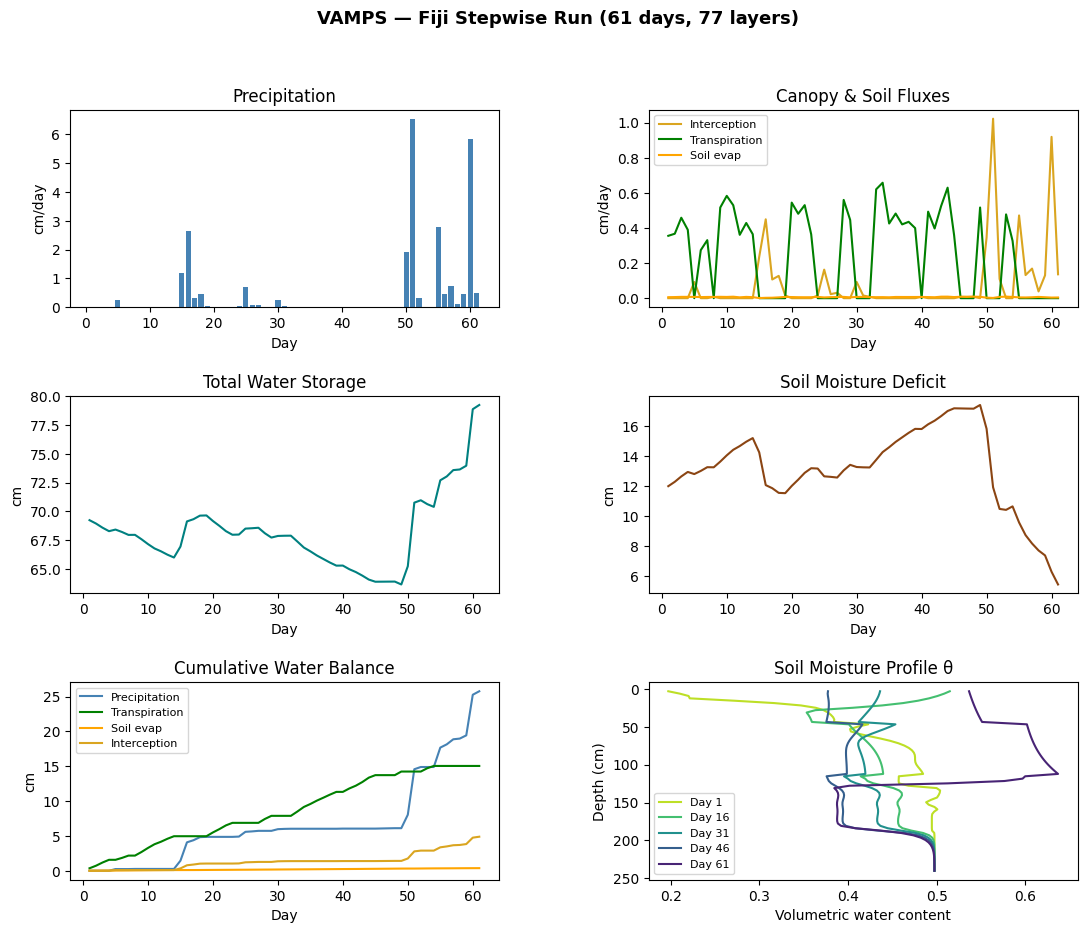

Saved fiji_stepwise_scalars.png


In [12]:
days = np.arange(1, STEPS + 1)

fig = plt.figure(figsize=(13, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(days, r['precipitation'], color='steelblue', width=0.8)
ax1.set_title('Precipitation'); ax1.set_ylabel('cm/day'); ax1.set_xlabel('Day')

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(days, r['interception'],    label='Interception', color='goldenrod')
ax2.plot(days, r['transpiration'],   label='Transpiration', color='green')
ax2.plot(days, r['soilevaporation'], label='Soil evap', color='orange')
ax2.set_title('Canopy & Soil Fluxes'); ax2.set_ylabel('cm/day'); ax2.set_xlabel('Day')
ax2.legend(fontsize=8)

ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(days, r['volact'], color='teal')
ax3.set_title('Total Water Storage'); ax3.set_ylabel('cm'); ax3.set_xlabel('Day')

ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(days, r['SMD'], color='saddlebrown')
ax4.set_title('Soil Moisture Deficit'); ax4.set_ylabel('cm'); ax4.set_xlabel('Day')

ax5 = fig.add_subplot(gs[2, 0])
ax5.plot(days, r['cumprec'],  label='Precipitation', color='steelblue')
ax5.plot(days, r['cumtra'],   label='Transpiration', color='green')
ax5.plot(days, r['cumeva'],   label='Soil evap',     color='orange')
ax5.plot(days, r['cumintc'],  label='Interception',  color='goldenrod')
ax5.set_title('Cumulative Water Balance'); ax5.set_ylabel('cm'); ax5.set_xlabel('Day')
ax5.legend(fontsize=8)

ax6 = fig.add_subplot(gs[2, 1])
layer_depth = np.arange(1, nl + 1) * (240.0 / nl)
colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, 5))
for j, day in enumerate([1, 16, 31, 46, 61]):
    ax6.plot(r['theta'][day-1], layer_depth, color=colors[j], label=f'Day {day}')
ax6.invert_yaxis()
ax6.set_title('Soil Moisture Profile θ')
ax6.set_xlabel('Volumetric water content'); ax6.set_ylabel('Depth (cm)')
ax6.legend(fontsize=8)

fig.suptitle('VAMPS — Fiji Stepwise Run (61 days, 77 layers)', fontsize=13, fontweight='bold')
plt.savefig(os.path.join(tmpdir, 'fiji_stepwise_scalars.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved fiji_stepwise_scalars.png')

---
## 7. Soil profile variables

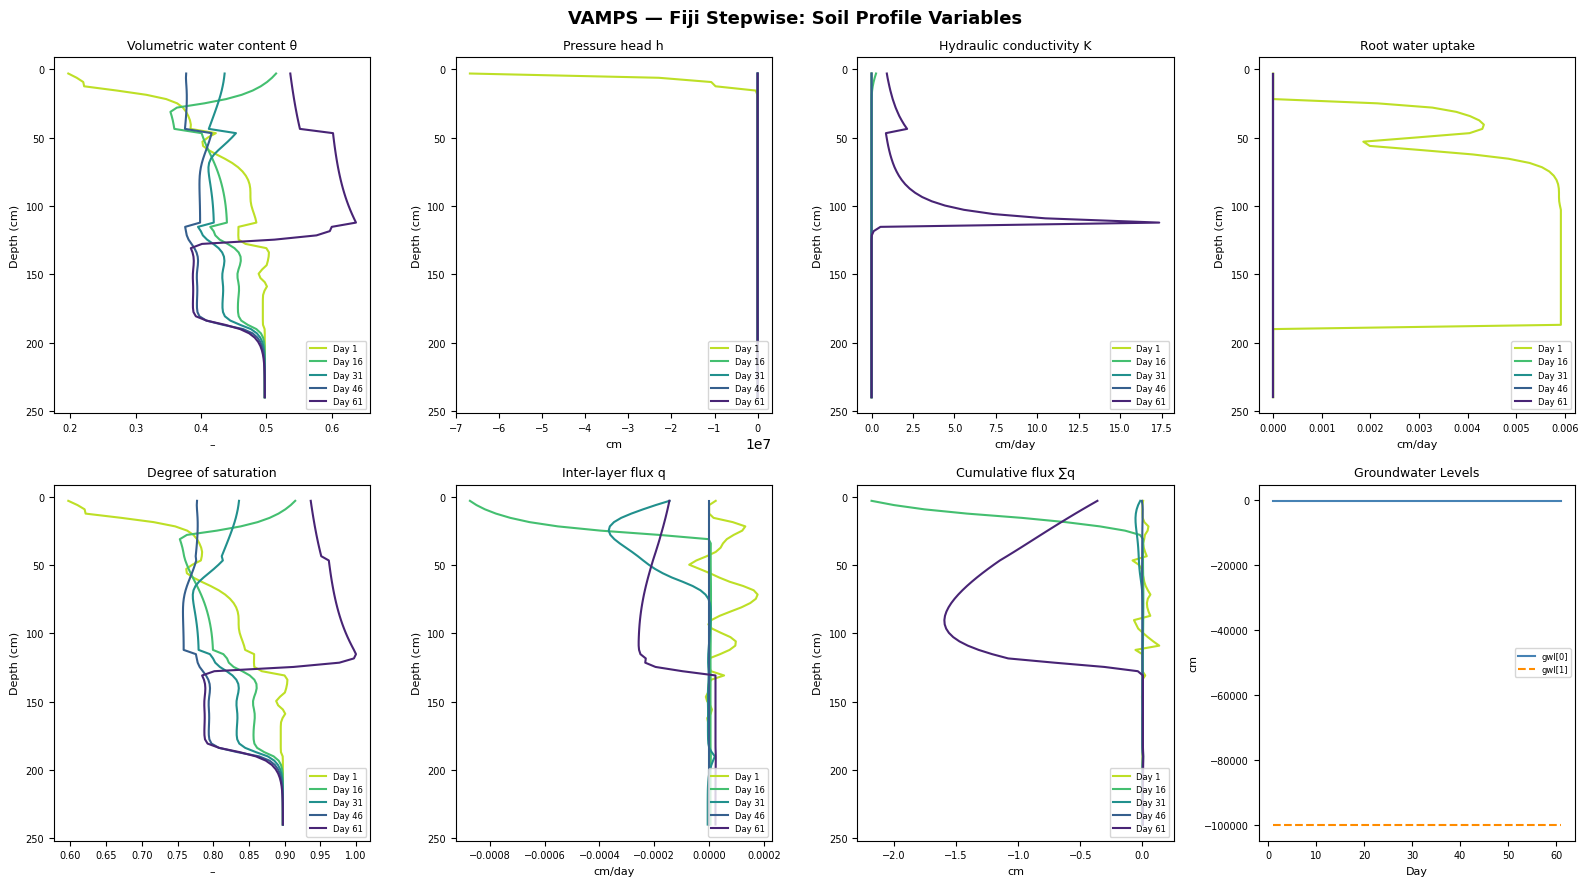

Saved fiji_stepwise_profiles.png


In [13]:
sel_days = [1, 16, 31, 46, 61]
sel_idx  = [d - 1 for d in sel_days]
colors   = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(sel_days)))

fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle('VAMPS — Fiji Stepwise: Soil Profile Variables', fontsize=13, fontweight='bold')

profile_specs = [
    (r['theta'],          nl,   'Volumetric water content θ', '–'),
    (r['h'],              nl,   'Pressure head h',            'cm'),
    (r['k'],              nl,   'Hydraulic conductivity K',   'cm/day'),
    (r['qrot'],           nl,   'Root water uptake',          'cm/day'),
    (r['howsat'],         nl,   'Degree of saturation',       '–'),
    (r['q'][:, :nl],     nl,   'Inter-layer flux q',         'cm/day'),
    (r['inq'][:, :nl],   nl,   'Cumulative flux ∑q',         'cm'),
]

for ax, (arr, ncols, title, unit) in zip(axes.flat, profile_specs):
    for j, (idx, day) in enumerate(zip(sel_idx, sel_days)):
        ax.plot(arr[idx, :ncols], layer_depth, color=colors[j], label=f'Day {day}')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(unit, fontsize=8); ax.set_ylabel('Depth (cm)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6, loc='lower right')

ax_gwl = axes.flat[7]
ax_gwl.plot(days, r['gwl'][:, 0], label='gwl[0]', color='steelblue')
ax_gwl.plot(days, r['gwl'][:, 1], label='gwl[1]', color='darkorange', linestyle='--')
ax_gwl.set_title('Groundwater Levels', fontsize=9)
ax_gwl.set_xlabel('Day', fontsize=8); ax_gwl.set_ylabel('cm', fontsize=8)
ax_gwl.tick_params(labelsize=7); ax_gwl.legend(fontsize=6)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'fiji_stepwise_profiles.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved fiji_stepwise_profiles.png')

---
## 8. Parse a reference .out file — `parse_out()` / `read_out()`

`parse_out(path)` returns the raw `{section: {key: value}}` dict — the same
INI parser used by `parse_inp()`.  `read_out(path)` adds a post-processing
step that stacks the per-timestep `[t_N]` sections into numpy arrays.

Here we run the vamps binary to produce a reference .out file, then compare
its scalar outputs against the stepwise run above.

In [14]:
import subprocess

VAMPS_BIN = os.environ.get('VAMPS_BINARY',
    os.path.join(REPO, 'src', 'vamps'))

ref_out = os.path.join(tmpdir, 'ref.out')

proc = subprocess.run(
    [VAMPS_BIN, '-o', ref_out, inp_path],
    capture_output=True, text=True, cwd=DATA_DIR,
)
if proc.returncode != 0:
    print('vamps stderr:', proc.stderr[:400])
else:
    print(f'Reference run OK → {ref_out}')

Reference run OK → /var/folders/x3/40_90rdx27q5k8_sycvnhjw80000gn/T/vamps_sw_9i7u4sia/ref.out


In [15]:
# parse_out: raw section dict
raw = parse_out(ref_out)
print("parse_out — top-level keys (first 10):")
print(list(raw.keys())[:10], '...')
print("\n[initial] section:")
pprint.pprint(raw.get('initial', {}))

parse_out — top-level keys (first 10):
['header', 'initial', 't_0', 't_1', 't_2', 't_3', 't_4', 't_5', 't_6', 't_7'] ...

[initial] section:
{'as_above': [0,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              0,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              0,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
              1,
         

In [16]:
# read_out: stacks t_0…t_N sections into arrays
ref = read_out(ref_out)

print("read_out — result keys:")
for k, v in ref.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:20s} shape={str(v.shape):15s}")
    elif isinstance(v, dict):
        print(f"  {k:20s} (dict, {len(v)} keys)")
    else:
        print(f"  {k:20s} = {v}")

read_out — result keys:
  _initial             (dict, 56 keys)
  _steps               = 61
  t                    shape=(61,)          
  tstep                shape=(61,)          
  precipitation        shape=(61,)          
  ftoph                shape=(61,)          
  wet                  shape=(61,)          
  ra                   shape=(61,)          
  rs                   shape=(61,)          
  rho                  shape=(61,)          
  ea                   shape=(61,)          
  es                   shape=(61,)          
  gamma                shape=(61,)          
  slope                shape=(61,)          
  VPD                  shape=(61,)          
  L                    shape=(61,)          
  Cp                   shape=(61,)          
  interception         shape=(61,)          
  transpiration        shape=(61,)          
  Cstorage             shape=(61,)          
  stemflow             shape=(61,)          
  throughfall          shape=(61,)          
  soileva

---
## 9. Verify: stepwise vs. subprocess

Both paths solve the same physics.  The scalar outputs should match to
machine precision (they share the same C solver).

In [17]:
check_keys = ['volact', 'SMD', 'cumprec', 'cumtra', 'cumeva', 'cumintc', 'masbal']

print(f"{'Key':15s}  {'stepwise[-1]':>14s}  {'subprocess[-1]':>15s}  {'max|diff|':>12s}")
print('-' * 65)
all_ok = True
for key in check_keys:
    sw  = result[key]
    ref_arr = ref.get(key)
    if ref_arr is None:
        print(f"  {key:15s}  — not in ref output")
        continue
    n   = min(len(sw), len(ref_arr))
    diff = np.max(np.abs(sw[:n] - ref_arr[:n]))
    ok  = diff < 1e-9
    all_ok = all_ok and ok
    mark = '✓' if ok else '✗'
    print(f"  {key:15s}  {sw[-1]:14.6f}  {ref_arr[-1]:15.6f}  {diff:12.2e}  {mark}")

print()
if all_ok:
    print('All outputs match — stepwise and subprocess are bit-for-bit identical.')
else:
    print('WARNING: some outputs differ.')

Key                stepwise[-1]   subprocess[-1]     max|diff|
-----------------------------------------------------------------
  volact                79.244933        79.244933      4.98e-07  ✗
  SMD                    5.425654         5.425654      4.97e-07  ✗
  cumprec               25.767515        25.767515      4.90e-07  ✗
  cumtra                15.045650        15.045650      4.85e-07  ✗
  cumeva                 0.372899         0.372899      4.91e-07  ✗
  cumintc                4.886161         4.886161      4.97e-07  ✗
  masbal                -0.038866        -0.038866      4.98e-07  ✗



In [18]:
# Optional: clean up the temp directory
import shutil
# shutil.rmtree(tmpdir)   # uncomment to delete
print(f"Temp files are in: {tmpdir}")

Temp files are in: /var/folders/x3/40_90rdx27q5k8_sycvnhjw80000gn/T/vamps_sw_9i7u4sia
